In [322]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [305]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv')
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(
    X,                      # Suas características (features)
    y,                      # Seu alvo (Revenue)
    test_size=0.3,          # 30% dos dados vão para teste
    random_state=42,        # Garante que o sorteio seja sempre igual
    stratify=y              # MANTÉM a proporção de compradores (muito importante!)
)

In [255]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


# E-commerce Customer Intent Dataset: Feature Description

This dataset consists of **12,330 sessions**, where **Revenue** serves as the target class (84.5% negative samples, 15.5% positive samples). Below is the detailed breakdown of the attributes:

## 1. Page Statistics

These features represent the types of pages visited and the time spent on them. They are updated in real-time based on URL information.

* **Administrative**: Number of administrative pages visited in the session.
* **Administrative_Duration**: Total time spent on administrative pages.
* **Informational**: Number of informational pages visited.
* **Informational_Duration**: Total time spent on informational pages.
* **ProductRelated**: Number of product-related pages visited.
* **ProductRelated_Duration**: Total time spent on product-related pages.

## 2. Google Analytics Metrics

These features are derived from standard e-commerce performance metrics.

* **BounceRates**: The percentage of visitors who enter the site from that page and leave ("bounce") without any further requests.
* **ExitRates**: The percentage of views to a page that were the last in the session.
* **PageValues**: The average value of a web page visited before completing a transaction.

## 3. Contextual and Temporal Features

* **SpecialDay**: Indicates the proximity to a special day (e.g., Valentine's Day).
* *Example:* For Valentine's Day, it reaches a maximum value of **1.0** on Feb 8th and returns to **0** after Feb 12th, accounting for shipping/delivery times.


* **Month**: The month of the year in which the session occurred.
* **Weekend**: A Boolean value (True/False) indicating if the visit happened on a weekend.

## 4. Technical and User Information

* **OperatingSystems**: The OS used by the visitor (encoded as integers).
* **Browser**: The browser used by the visitor (encoded as integers).
* **Region**: The geographic region of the visitor.
* **TrafficType**: The source of traffic that brought the user to the site.
* **VisitorType**: Whether the user is a `New_Visitor`, `Returning_Visitor`, or `Other`.

## 5. Target Variable

* **Revenue**: A Boolean value (True/False) indicating whether the session finalized in a purchase.

---

### Dataset Summary Table

| Attribute Category | Count | Type |
| --- | --- | --- |
| **Numerical** | 10 | int64, float64 |
| **Categorical/Other** | 8 | object, bool |
| **Total Samples** | 12,330 | - |

## EDA

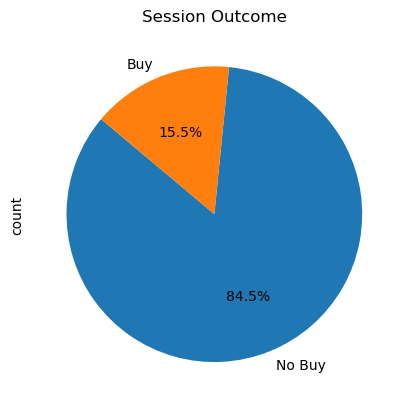

In [200]:
label_map = {True: 'Buy', False: 'No Buy'}

df['Revenue'].map(label_map).value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=140,
    title="Session Outcome"
)
plt.show()

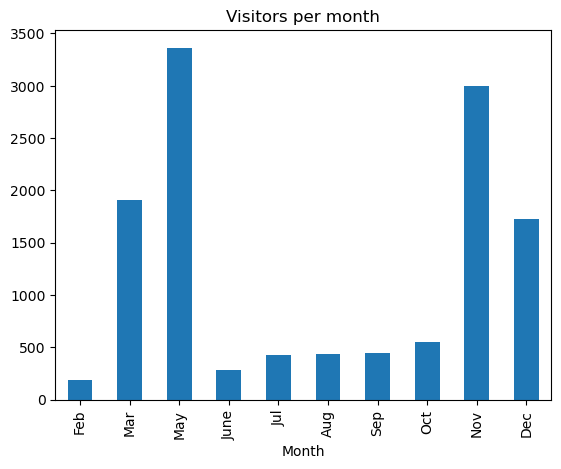

In [219]:
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
df['Month'].value_counts().sort_index().plot(kind="bar")
plt.title('Visitors per month')
plt.show()

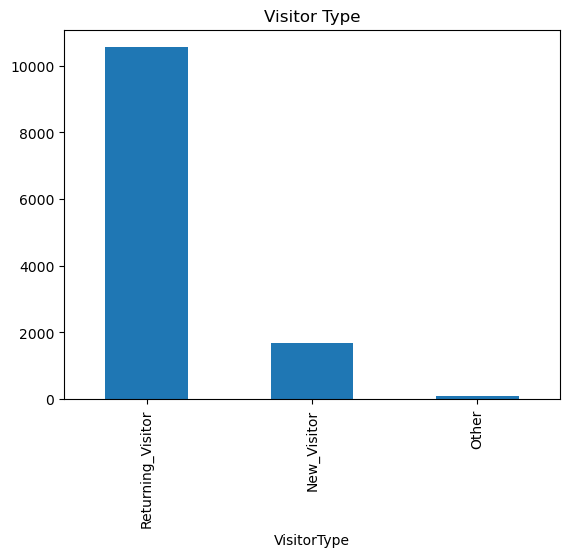

In [217]:
df['VisitorType'].value_counts().plot(kind="bar")
plt.title('Visitor Type')
plt.show()

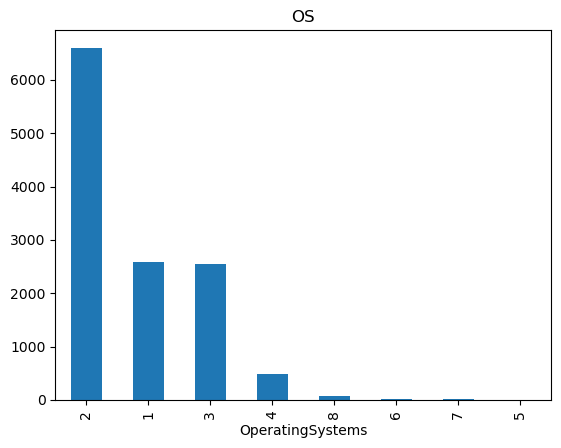

In [216]:
df['OperatingSystems'].value_counts().plot(kind="bar")
plt.title('OS')
plt.show()

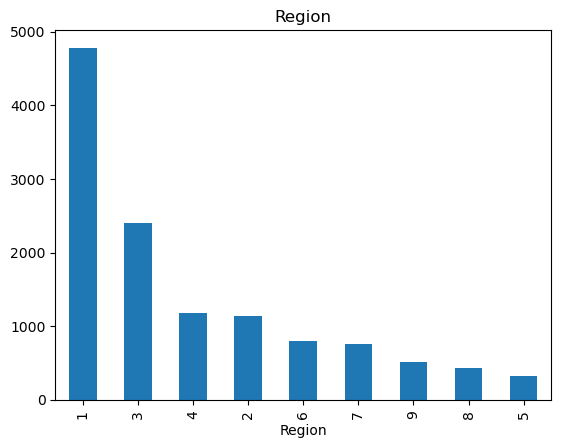

In [214]:
df['Region'].value_counts().plot(kind="bar")
plt.title('Region')
plt.show()

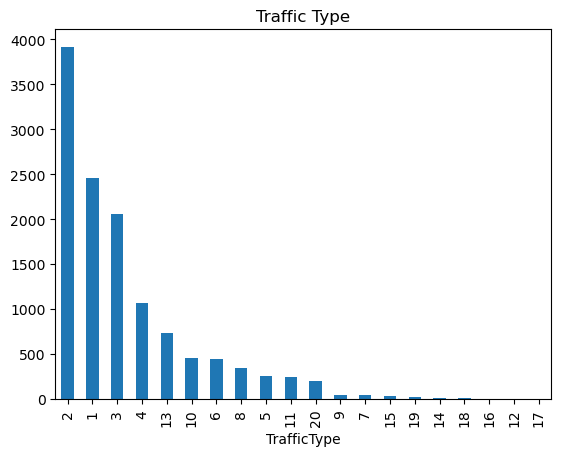

In [309]:
df['TrafficType'].value_counts().plot(kind="bar")
plt.title('Traffic Type')
plt.show()

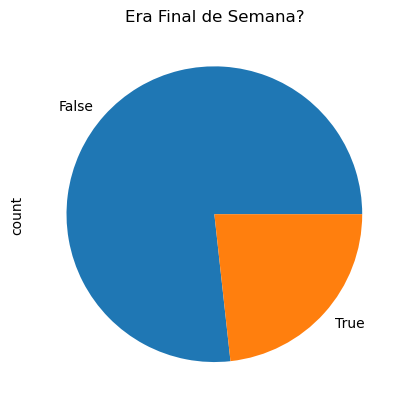

In [212]:
df['Weekend'].value_counts().plot.pie()
plt.title('Era Final de Semana?')
plt.show()

In [262]:
buyers_df = df[df['Revenue']==True].copy()

In [265]:
buyers_df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
65,3,87.833333,0,0.0,27,798.333333,0.000000,0.012644,22.916036,0.8,Feb,2,2,3,1,Returning_Visitor,False,True
76,10,1005.666667,0,0.0,36,2111.341667,0.004348,0.014493,11.439412,0.0,Feb,2,6,1,2,Returning_Visitor,False,True
101,4,61.000000,0,0.0,19,607.000000,0.000000,0.026984,17.535959,1.0,Feb,1,1,7,4,Returning_Visitor,True,True
188,9,111.500000,1,48.5,49,1868.819697,0.000000,0.020709,1.706015,0.0,Mar,2,2,7,2,Returning_Visitor,False,True
196,2,56.000000,1,144.0,67,2563.783333,0.000000,0.005797,19.342650,0.0,Mar,2,2,4,2,New_Visitor,False,True


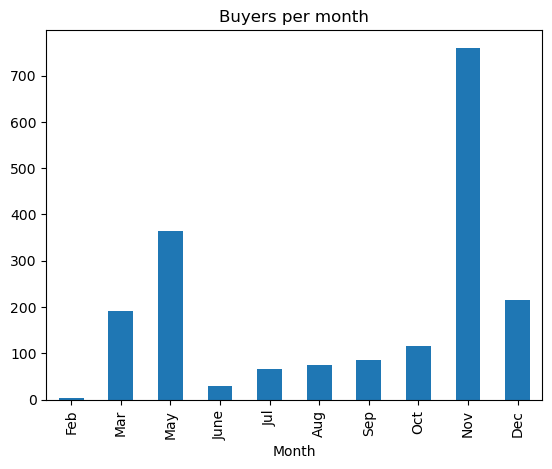

In [264]:
month_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
buyers_df['Month'] = pd.Categorical(buyers_df['Month'], categories=month_order, ordered=True)
buyers_df['Month'].value_counts().sort_index().plot(kind="bar")
plt.title('Buyers per month')
plt.show()

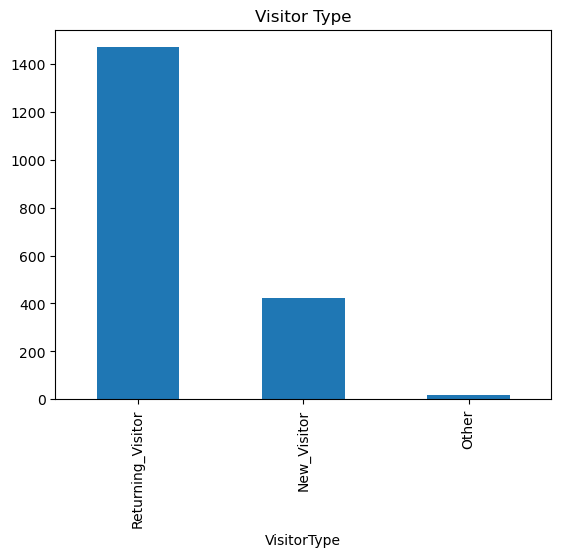

In [266]:
buyers_df['VisitorType'].value_counts().plot(kind="bar")
plt.title('Visitor Type')
plt.show()

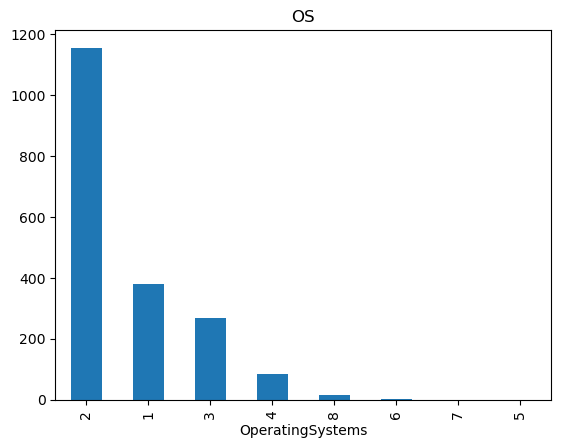

In [267]:
buyers_df['OperatingSystems'].value_counts().plot(kind="bar")
plt.title('OS')
plt.show()

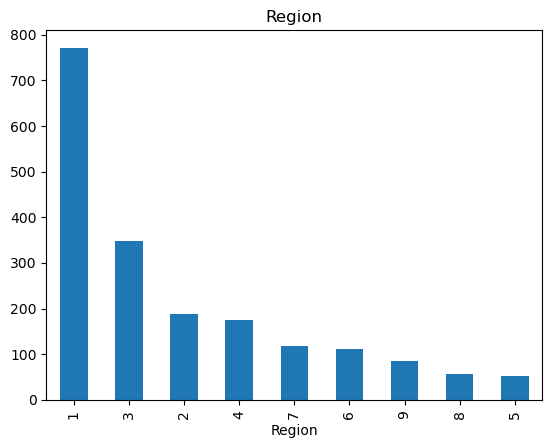

In [268]:
buyers_df['Region'].value_counts().plot(kind="bar")
plt.title('Region')
plt.show()

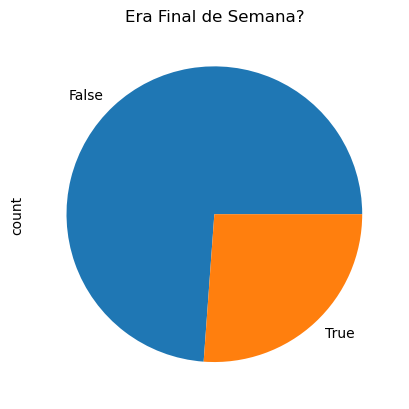

In [269]:
buyers_df['Weekend'].value_counts().plot.pie()
plt.title('Era Final de Semana?')
plt.show()

In [257]:
buyers_df.shape

(1908, 18)

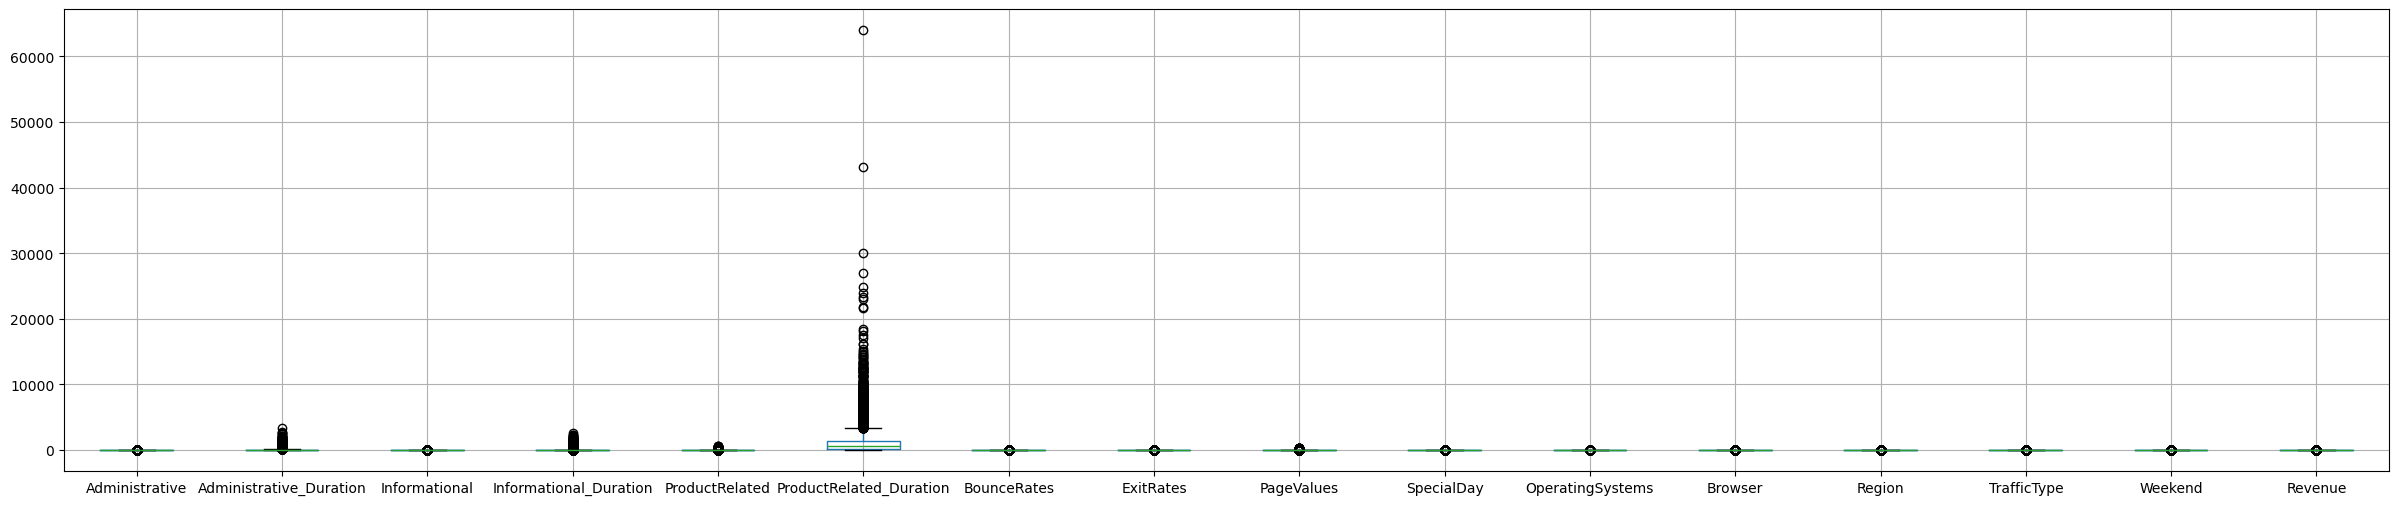

In [270]:
plt.figure(figsize=(30, 6))
df.boxplot()
plt.show()

In [275]:
df[df['ProductRelated_Duration'] > 3600].shape[0]

867

In [276]:
df[df['ProductRelated_Duration'] > 3600].shape[0]/df.shape[0]*100

7.031630170316301

## Data Processing

In [310]:
processed_df = pd.get_dummies(df, columns=['Month', 'VisitorType'])

In [311]:
processed_df.head(100)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,0.0,0,0.0,2,33.000000,0.000000,0.100000,0.0,0.2,...,False,False,False,False,False,False,False,False,False,True
96,0,0.0,0,0.0,6,1566.500000,0.050000,0.066667,0.0,0.2,...,False,False,False,False,False,False,False,False,False,True
97,0,0.0,0,0.0,4,105.000000,0.000000,0.025000,0.0,0.6,...,False,False,False,False,False,False,False,False,False,True
98,0,0.0,1,0.0,7,50.000000,0.038095,0.080952,0.0,0.6,...,False,False,False,False,False,False,False,False,False,True


In [312]:
processed_df.shape

(12330, 29)

In [313]:
# Criando a lista de colunas que você quer escalonar
colunas_para_escalonar = [
    'Administrative', 'Administrative_Duration', 'Informational', 
    'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 
    'OperatingSystems', 'Browser', 'Region', 'TrafficType'
]

# Aplicando o fit_transform apenas nessas colunas
processed_df[colunas_para_escalonar] = scaler.fit_transform(df[colunas_para_escalonar])

In [314]:
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  float64
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  float64
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  float64
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  float64
 11  Browser                        12330 non-null  float64
 12  Region                         12330 non-null 

In [147]:
processed_df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04,1.233000e+04
mean,-2.766103e-17,5.993223e-17,-2.305086e-17,-1.613560e-17,4.610172e-17,-8.298309e-17,-5.993223e-17,3.688137e-17,9.220344e-18,1.475255e-16,-4.610172e-18,1.613560e-17,6.338986e-17,-1.613560e-17
std,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00,1.000041e+00
min,-6.969930e-01,-4.571914e-01,-3.964779e-01,-2.449305e-01,-7.134884e-01,-6.243475e-01,-4.576830e-01,-8.863706e-01,-3.171778e-01,-3.088214e-01,-1.233426e+00,-7.902929e-01,-8.941785e-01,-7.626290e-01
25%,-6.969930e-01,-4.571914e-01,-3.964779e-01,-2.449305e-01,-5.560920e-01,-5.281214e-01,-4.576830e-01,-5.923930e-01,-3.171778e-01,-3.088214e-01,-1.360783e-01,-2.079519e-01,-8.941785e-01,-5.141822e-01
50%,-3.959377e-01,-4.147639e-01,-3.964779e-01,-2.449305e-01,-3.087548e-01,-3.113566e-01,-3.934903e-01,-3.686913e-01,-3.171778e-01,-3.088214e-01,-1.360783e-01,-2.079519e-01,-6.136354e-02,-5.141822e-01
75%,5.072280e-01,7.035981e-02,-3.964779e-01,-2.449305e-01,1.409492e-01,1.407881e-01,-1.109348e-01,1.425510e-01,-3.171778e-01,-3.088214e-01,9.612698e-01,-2.079519e-01,3.550439e-01,-1.728851e-02
max,7.431499e+00,1.876956e+01,1.849960e+01,1.786868e+01,1.513858e+01,3.280678e+01,3.667189e+00,3.229316e+00,1.916634e+01,4.718598e+00,6.448010e+00,6.197799e+00,2.437081e+00,3.957861e+00


In [148]:
processed_df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,False,False,False,False,False,False,False,False,False,True
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,...,False,False,False,False,False,False,False,False,False,True
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,False,False,False,False,False,False,False,False,False,True
3,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.622954,0.573535,1.994610,-0.317178,-0.308821,...,False,False,False,False,False,False,False,False,False,True
4,-0.696993,-0.457191,-0.396478,-0.244931,-0.488636,-0.296430,-0.045196,0.142551,-0.317178,-0.308821,...,False,False,False,False,False,False,False,False,False,True


## training and testing

In [315]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [316]:
len(X_train), len(y_train)

(8631, 8631)

In [317]:
len(X_test), len(y_test)

(3699, 3699)